# Laporan: Migrasi Data Time Series ke PostgreSQL (Aiven) dan Analisis Statistik Deskriptif di KNIME

## 1. Deskripsi Tugas

Tugas ini terdiri dari tiga tahap utama:
1. Memindahkan data time series polutan (hasil crawling) dari file CSV ke database PostgreSQL yang di-hosting di Aiven Cloud.
2. Menarik (membaca) data tersebut dari PostgreSQL ke dalam KNIME Analytics Platform menggunakan workflow database node.
3. Melakukan analisis statistik deskriptif terhadap data menggunakan node **Statistics** di KNIME, lengkap dengan rumus dan contoh perhitungan setiap fitur (kolom statistik) yang dihasilkan.

---

## 2. Tahap 1 — Migrasi Data ke PostgreSQL (Aiven)

Data awal berupa file `hasil_crawling_polutan.csv` dengan kolom `date`, `pollutant`, dan `value` (format *long/tall*, setiap baris mewakili satu jenis polutan pada satu tanggal).

**Alur migrasi (Python):**
1. Baca file CSV menggunakan `pandas.read_csv()`.
2. Ubah nama kolom menjadi huruf kecil agar konsisten dengan skema database.
3. Buat koneksi ke PostgreSQL Aiven menggunakan `sqlalchemy.engine.URL.create()` dan `create_engine()`, dengan parameter:
   - `drivername = "postgresql+psycopg2"`
   - `host`, `port`, `database`, `username`, `password`
   - `query = {"sslmode": "require"}` (wajib karena Aiven mensyaratkan koneksi terenkripsi SSL)
4. Masukkan data ke tabel `data_polutan` menggunakan `df.to_sql("data_polutan", engine, if_exists="append", index=False)`.
5. Verifikasi dengan membaca kembali data menggunakan `pandas.read_sql()` dan mengecek jumlah baris.

Bukti eksekusi skrip migrasi di terminal (pembacaan CSV, koneksi ke Aiven, hingga verifikasi ulang jumlah baris):

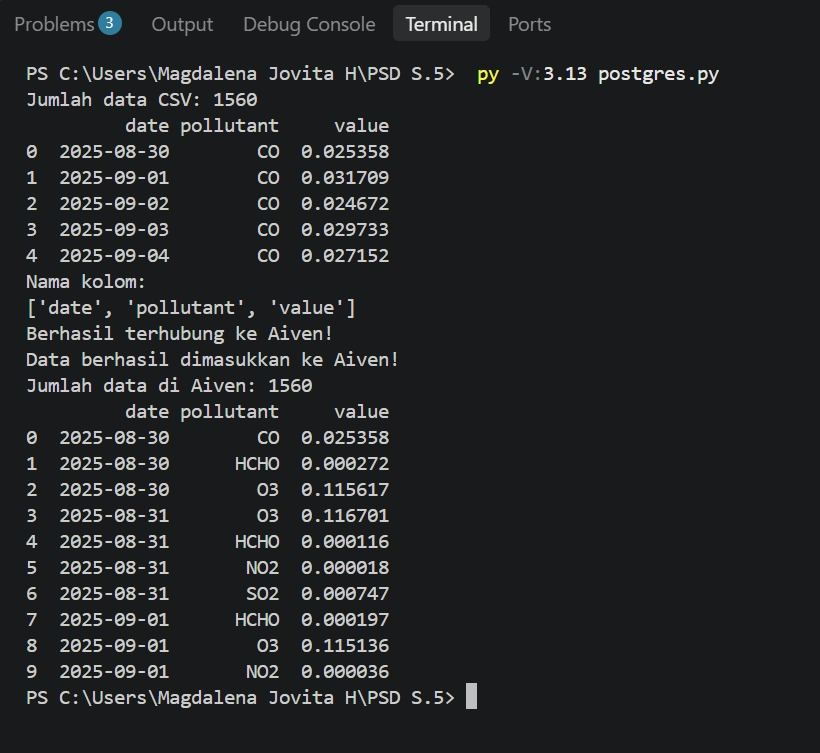

**Hasil verifikasi:**
- Jumlah baris di CSV: **1560**
- Jumlah baris di database Aiven setelah migrasi: **1560**

Verifikasi independen langsung di Aiven Console (PG Studio) dengan query `SELECT COUNT(*) FROM data_polutan;` juga mengembalikan **1560**, cocok dengan jumlah baris di CSV asal — menandakan tidak ada baris yang hilang selama proses migrasi:

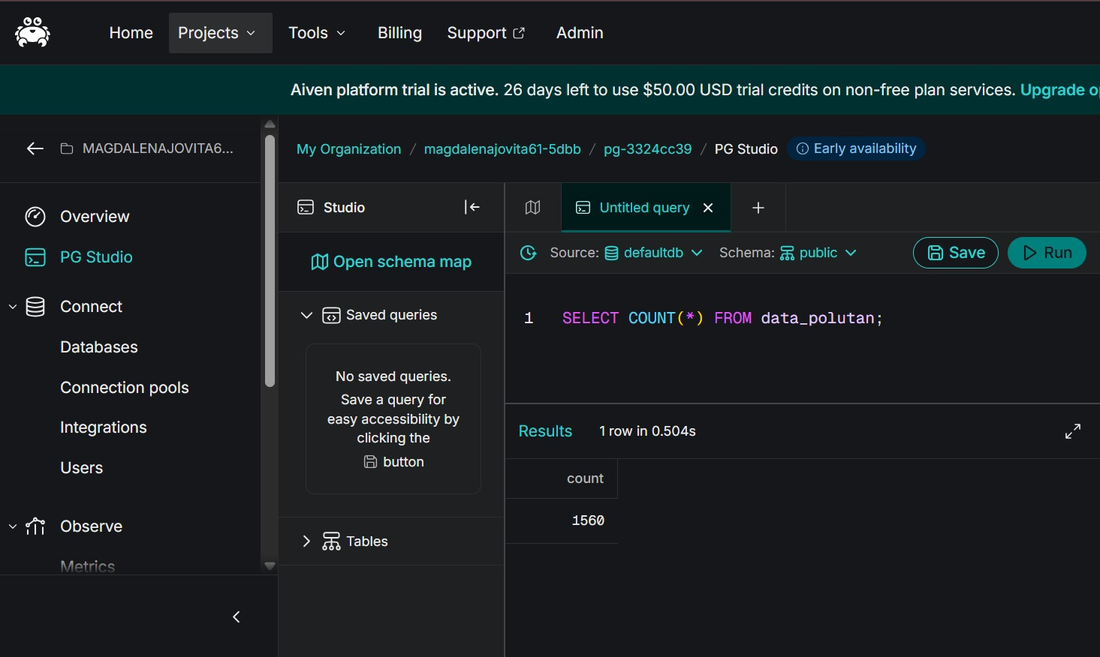

---

## 3. Tahap 2 — Menarik Data ke KNIME

Workflow KNIME dibangun dengan urutan node berikut:

**PostgreSQL Connector → DB Table Selector → DB Reader → Statistics**

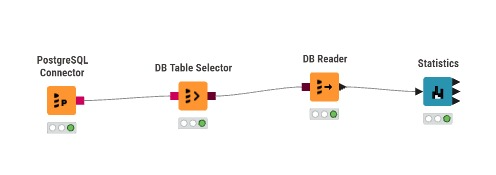

| Node | Fungsi |
|---|---|
| **PostgreSQL Connector** | Membuat koneksi ke database Aiven (hostname, database name, dan autentikasi username/password). |
| **DB Table Selector** | Memilih tabel sumber data, dalam hal ini schema `public`, tabel `data_polutan`. |
| **DB Reader** | Mengeksekusi query dan menarik seluruh data dari tabel ke dalam KNIME sebagai tabel kerja (in-memory table). |
| **Statistics** | Menghitung ringkasan statistik deskriptif dari kolom numerik (`value`). |

Konfigurasi PostgreSQL Connector (hostname, database, dan autentikasi username/password ke Aiven):

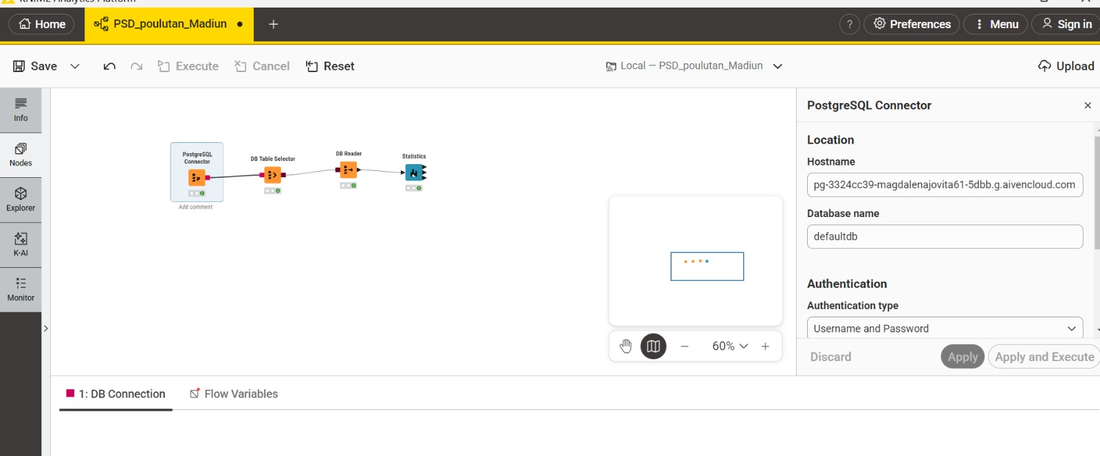

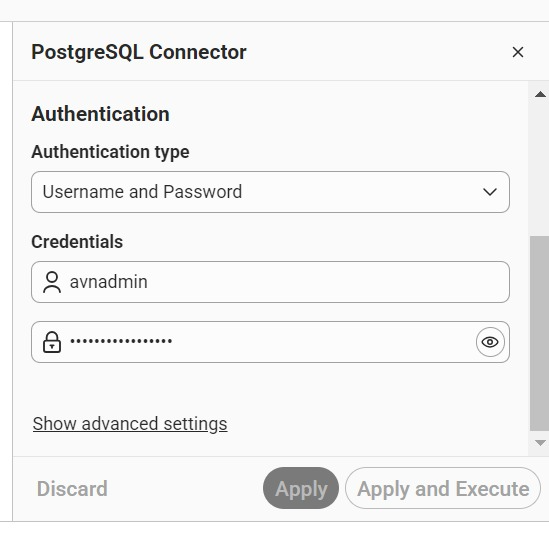

Konfigurasi DB Table Selector — menunjuk schema `public` dan tabel `data_polutan`:

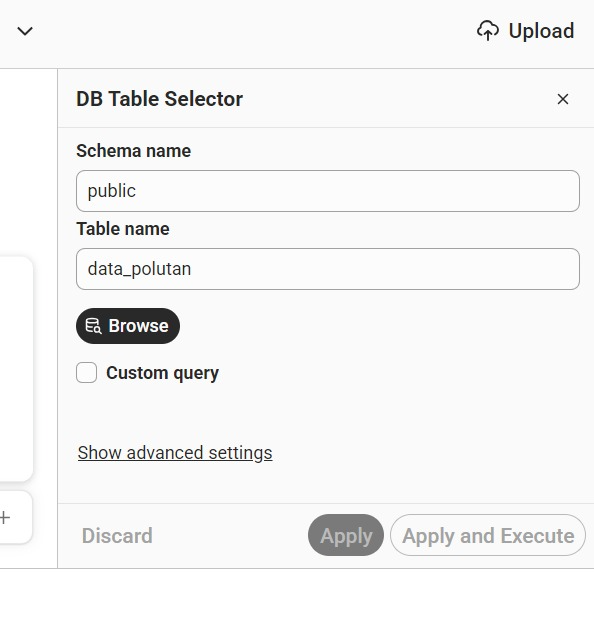

Hasil DB Reader menunjukkan 1560 baris, 3 kolom (`date`, `pollutant`, `value`) — sama persis dengan jumlah data di Aiven, artinya proses penarikan data berhasil sempurna tanpa kehilangan data:

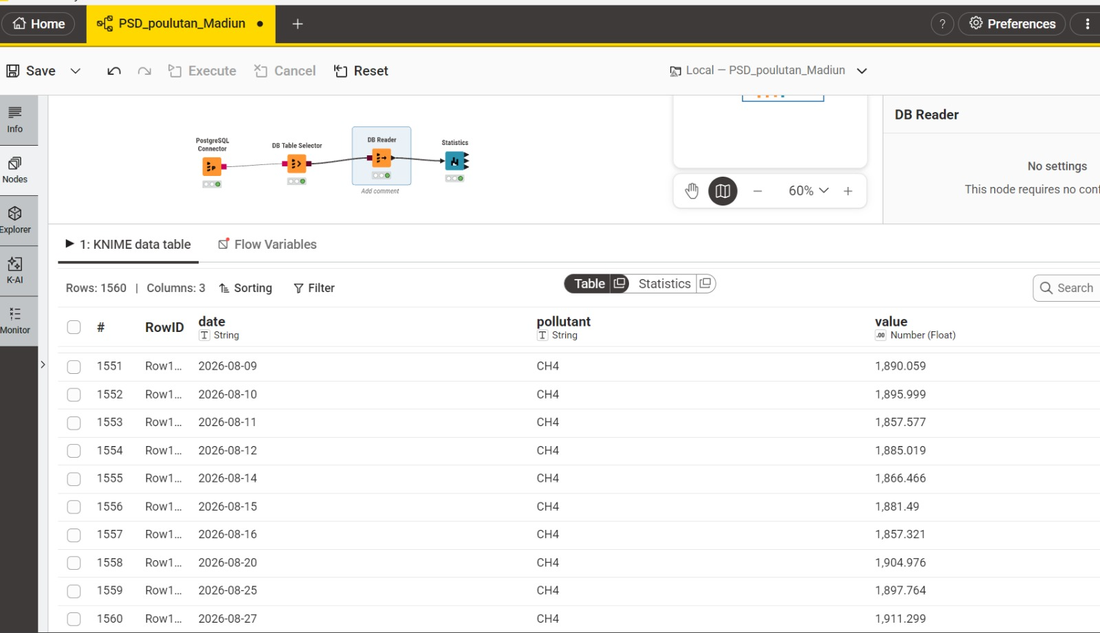

---

## 4. Tahap 3 — Analisis Statistik Deskriptif (Node Statistics)

Node Statistics menghasilkan **16 kolom ringkasan** untuk kolom numerik `value`. Berikut penjelasan, rumus, dan contoh perhitungan setiap fitur.

Sebagai ilustrasi perhitungan manual, digunakan contoh data sederhana:

$$x = \{2,\ 4,\ 4,\ 4,\ 5,\ 5,\ 7,\ 9\}, \quad n = 8$$

### 4.1 No. of Rows (Jumlah Baris)
Banyaknya baris data pada kolom yang dianalisis.

$$N = \text{banyaknya baris data}$$

**Contoh:** data di atas ada 8 nilai, jadi **N = 8**.

### 4.2 No. Missings (Jumlah Nilai Hilang)
Jumlah baris di mana nilai kosong/null pada saat data dibaca dari sumber (misalnya sel kosong di database atau CSV).

$$\text{No. Missings} = \text{jumlah baris dengan value} = \text{NULL}$$

**Contoh:** dari 8 data di atas tidak ada yang kosong, jadi **No. Missings = 0**.

### 4.3 No. NaNs (Jumlah Not-a-Number)
Jumlah nilai yang gagal diproses sebagai angka (misalnya hasil pembagian tidak valid, error parsing, atau representasi non-numerik pada kolom numerik).

$$\text{No. NaNs} = \text{jumlah baris dengan value} = \text{NaN}$$

**Contoh:** **No. NaNs = 0**, seluruh 8 nilai berhasil terbaca sebagai angka valid.

### 4.4 Min (Nilai Minimum)
Nilai terkecil dalam kumpulan data.

$$\text{Min} = \min(x_1, x_2, ..., x_n)$$

**Contoh:** Min dari data di atas = **2**

### 4.5 Max (Nilai Maksimum)
Nilai terbesar dalam kumpulan data.

$$\text{Max} = \max(x_1, x_2, ..., x_n)$$

**Contoh:** Max dari data di atas = **9**

### 4.6 Overall Sum (Jumlah Total)
Total penjumlahan seluruh nilai.

$$\text{Sum} = \sum_{i=1}^{n} x_i$$

**Contoh:**
$$2+4+4+4+5+5+7+9 = 40$$

### 4.7 Mean (Rata-rata)
Nilai tengah/rata-rata dari seluruh data.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Contoh:**
$$\bar{x} = \frac{40}{8} = 5$$

### 4.8 Median (Nilai Tengah)
Nilai yang berada tepat di tengah data **setelah diurutkan**. Kalau n genap, diambil rata-rata dua nilai tengah.

$$
\text{Median} =
\begin{cases}
x_{\left(\frac{n+1}{2}\right)} & n \text{ ganjil} \\
\dfrac{x_{(n/2)} + x_{(n/2+1)}}{2} & n \text{ genap}
\end{cases}
$$

**Contoh:** data terurut $2,4,4,4,5,5,7,9$ ($n=8$, genap), dua nilai tengah adalah data ke-4 dan ke-5 yaitu 4 dan 5.

$$\text{Median} = \frac{4+5}{2} = 4{,}5$$

### 4.9 First Quartile / Q1 (Kuartil Bawah)
Nilai yang membatasi 25% data terkecil. Dihitung dengan interpolasi linear pada data yang sudah diurutkan, posisinya $0{,}25\times(n-1)$.

**Contoh:** posisi $= 0{,}25 \times 7 = 1{,}75$, berada di antara data ke-2 dan ke-3 (index 1 dan 2, keduanya bernilai 4).

$$Q_1 = 4 + 0{,}75\times(4-4) = 4$$

### 4.10 Third Quartile / Q3 (Kuartil Atas)
Nilai yang membatasi 75% data terkecil (25% data terbesar). Posisinya $0{,}75\times(n-1)$.

**Contoh:** posisi $= 0{,}75 \times 7 = 5{,}25$, berada di antara data ke-6 (index 5, nilai 5) dan data ke-7 (index 6, nilai 7).

$$Q_3 = 5 + 0{,}25\times(7-5) = 5{,}5$$

### 4.11 Variance (Varians)
Ukuran seberapa jauh sebaran data terhadap rata-ratanya (dalam satuan kuadrat).

$$\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

**Contoh (langkah perhitungan):**

| xᵢ | xᵢ − x̄ | (xᵢ − x̄)² |
|---|---|---|
| 2 | -3 | 9 |
| 4 | -1 | 1 |
| 4 | -1 | 1 |
| 4 | -1 | 1 |
| 5 | 0 | 0 |
| 5 | 0 | 0 |
| 7 | 2 | 4 |
| 9 | 4 | 16 |

$$\sigma^2 = \frac{9+1+1+1+0+0+4+16}{8} = \frac{32}{8} = 4$$

### 4.12 Std. Deviation (Standar Deviasi)
Akar kuadrat dari varians; menyatakan sebaran data dalam satuan yang sama dengan data asli.

$$\sigma = \sqrt{\sigma^2}$$

**Contoh:**
$$\sigma = \sqrt{4} = 2$$

### 4.13 Skewness (Kemencengan Distribusi)
Mengukur asimetri distribusi data.
- Skewness = 0 → distribusi simetris
- Skewness > 0 → ekor memanjang ke kanan (positif)
- Skewness < 0 → ekor memanjang ke kiri (negatif)

$$\text{Skewness} = \frac{\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^3}{\sigma^3}$$

**Contoh (langkah perhitungan):**

Jumlah (xᵢ − x̄)³ = (-3)³ + (-1)³×3 + 0³×2 + 2³ + 4³
$$= -27 - 3 + 0 + 8 + 64 = 42$$

$$m_3 = \frac{42}{8} = 5{,}25$$

$$\text{Skewness} = \frac{5{,}25}{2^3} = \frac{5{,}25}{8} = 0{,}656$$

Nilai positif kecil ini menunjukkan distribusi sedikit condong ke kanan.

### 4.14 Kurtosis (Keruncingan Distribusi)
Mengukur seberapa runcing/datar suatu distribusi dibanding distribusi normal. Yang biasa dilaporkan adalah **excess kurtosis** (dikurangi 3, karena distribusi normal punya kurtosis = 3).

$$\text{Kurtosis (excess)} = \frac{\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^4}{\sigma^4} - 3$$

**Contoh (langkah perhitungan):**

Jumlah (xᵢ − x̄)⁴ = (-3)⁴ + (-1)⁴×3 + 0⁴×2 + 2⁴ + 4⁴
$$= 81 + 3 + 0 + 16 + 256 = 356$$

$$m_4 = \frac{356}{8} = 44{,}5$$

$$\text{Kurtosis (excess)} = \frac{44{,}5}{2^4} - 3 = \frac{44{,}5}{16} - 3 = 2{,}78 - 3 = -0{,}22$$

Nilai negatif menunjukkan distribusi sedikit lebih datar (*platykurtic*) dibanding distribusi normal.

### 4.15 No. Unique Values (Jumlah Nilai Unik)
Banyaknya nilai yang berbeda (tanpa duplikat) pada kolom tersebut.

$$\text{No. Unique Values} = \left|\{x_1, x_2, \dots, x_n\}\right|$$

**Contoh:** dari data $\{2,4,4,4,5,5,7,9\}$, nilai yang berbeda adalah $\{2,4,5,7,9\}$, jadi **No. Unique Values = 5**.

### 4.16 Column Type (Tipe Kolom)
Menunjukkan tipe data kolom yang dianalisis, ditentukan otomatis oleh KNIME berdasarkan struktur data yang ditarik dari database.

**Contoh:** kolom `value` bertipe **Number (double)**, sedangkan kolom `pollutant` dan `date` bertipe **String**.

---

## 5. Ringkasan Hasil Statistik Data Aktual

Dari node Statistics terhadap kolom `value` (seluruh jenis polutan digabung, 1560 baris):

| Statistik | Nilai |
|---|---|
| No. of Rows | 1.560 |
| No. Missings | 0 |
| No. NaNs | 0 |
| Min | -0 |
| Max | 1.916,096 |
| Overall Sum | 92.628,043 |
| Mean | 59,377 |
| Variance | 108.676,343 |
| Std. Deviation | 329,661 |
| Skewness | 5,379 |
| Kurtosis | 26,97 |
| No. Unique Values (pollutant) | 6 |

**Interpretasi singkat:**
- Skewness yang tinggi (5,379) menunjukkan distribusi data sangat condong ke kanan — wajar karena kolom `value` menggabungkan polutan dengan skala sangat berbeda (misalnya CO/O3 bernilai < 1, sementara CH4 bernilai > 1000).
- Kurtosis yang sangat tinggi (26,97) menunjukkan distribusi memiliki ekor yang sangat panjang (banyak nilai ekstrem), konsisten dengan penggabungan skala nilai yang berbeda jauh antar jenis polutan.
- Tidak ada missing value maupun NaN, menandakan proses migrasi data dari CSV ke Aiven berjalan tanpa kehilangan data.
- Karena keenam polutan (CO, HCHO, O3, NO2, SO2, CH4) berada pada skala yang jauh berbeda, statistik gabungan di atas (Mean, Std. Deviation, Skewness, Kurtosis) sebaiknya dibaca sebagai gambaran kasar saja. Untuk analisis yang lebih bermakna, node Statistics idealnya dijalankan **per jenis polutan** (misalnya dengan menambah node *GroupBy* atau *Row Filter* sebelum node Statistics), bukan atas kolom `value` yang mencampur semua skala sekaligus.